# 🖼️ Image Captioning Demo

## Visual Narrator: CNN-LSTM with Attention

**BLEU-4 Score: 0.2457** (Paper: 0.2255) ✅

This notebook demonstrates automatic image captioning using:
- **Encoder:** ResNet-50 (pretrained on ImageNet)
- **Decoder:** LSTM with Bahdanau Attention
- **Dataset:** Flickr8k

---

## 1. Setup & Load Model

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import random

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1
CUDA available: False


In [3]:
# Model architecture (same as train.py)

class EncoderCNN(nn.Module):
    """ResNet-50 based encoder"""
    def __init__(self, encoded_image_size=14, encoder_dim=512):
        super().__init__()
        self.enc_image_size = encoded_image_size
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        modules = list(resnet.children())[:-2]
        self.cnn = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((encoded_image_size, encoded_image_size))
        self.conv_project = nn.Conv2d(2048, encoder_dim, kernel_size=1, stride=1)
        for p in self.cnn.parameters():
            p.requires_grad = False

    def forward(self, images):
        features = self.cnn(images)
        features = self.adaptive_pool(features)
        features = self.conv_project(features)
        B, D, H, W = features.size()
        features = features.permute(0, 2, 3, 1).view(B, -1, D)
        return features


class BahdanauAttention(nn.Module):
    """Additive attention mechanism"""
    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attention_dim)
        self.decoder_att = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)

    def forward(self, encoder_out, decoder_hidden):
        att1 = self.encoder_att(encoder_out)
        att2 = self.decoder_att(decoder_hidden).unsqueeze(1)
        att = self.full_att(self.relu(att1 + att2)).squeeze(2)
        alpha = self.softmax(att)
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)
        return context, alpha


class DecoderWithAttention(nn.Module):
    """LSTM decoder with attention"""
    def __init__(self, vocab_size, embed_dim, encoder_dim, decoder_dim, attention_dim, pad_idx):
        super().__init__()
        self.encoder_dim = encoder_dim
        self.decoder_dim = decoder_dim
        self.attention = BahdanauAttention(encoder_dim, decoder_dim, attention_dim)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.init_h = nn.Linear(encoder_dim, decoder_dim)
        self.init_c = nn.Linear(encoder_dim, decoder_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + encoder_dim, decoder_dim)
        self.f_beta = nn.Linear(decoder_dim, encoder_dim)
        self.sigmoid = nn.Sigmoid()
        self.fc = nn.Linear(decoder_dim, vocab_size)
        self.dropout = nn.Dropout(0.5)

    def init_hidden_state(self, encoder_out):
        mean_encoder = encoder_out.mean(dim=1)
        h = self.init_h(mean_encoder)
        c = self.init_c(mean_encoder)
        return h, c


class Vocabulary:
    def __init__(self, itos, stoi):
        self.itos = itos
        self.stoi = stoi
    def __len__(self):
        return len(self.itos)


print("✓ Model classes defined")

✓ Model classes defined


In [4]:
# Load trained model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Loading model on {device}...")

checkpoint = torch.load('best_model.pth', map_location=device)
vocab = Vocabulary(checkpoint['vocab']['itos'], checkpoint['vocab']['stoi'])
config = checkpoint['config']

encoder = EncoderCNN(encoder_dim=config['encoder_dim']).to(device)
decoder = DecoderWithAttention(
    vocab_size=len(vocab),
    embed_dim=config['embed_dim'],
    encoder_dim=config['encoder_dim'],
    decoder_dim=config['decoder_dim'],
    attention_dim=config['attention_dim'],
    pad_idx=vocab.stoi['<pad>']
).to(device)

encoder.load_state_dict(checkpoint['encoder'])
decoder.load_state_dict(checkpoint['decoder'])
encoder.eval()
decoder.eval()

print(f"✓ Model loaded successfully!")
print(f"  Vocabulary size: {len(vocab)}")
print(f"  BLEU-4 Score: 0.2457")
print(f"  Paper Score: 0.2255")
print(f"  Improvement: +9%")

Loading model on cpu...


C:\Users\simbe\AppData\Local\Temp\ipykernel_31816\1532234028.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_model.pth', map_location=devic

✓ Model loaded successfully!
  Vocabulary size: 2662
  BLEU-4 Score: 0.2457
  Paper Score: 0.2255
  Improvement: +9%


## 2. Caption Generation Function

In [6]:
# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


@torch.no_grad()
def generate_caption_with_attention(image_path, max_len=20):
    """
    Generate caption for an image and return attention weights
    
    Returns:
        caption: Generated caption string
        alphas: Attention weights for each word
        image: Original PIL image
    """
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # Encode image
    encoder_out = encoder(img_tensor)
    h, c = decoder.init_hidden_state(encoder_out)
    
    # Generate caption word by word
    start_idx = vocab.stoi['<start>']
    end_idx = vocab.stoi['<end>']
    
    caption_words = []
    alphas_list = []
    word_idx = start_idx
    
    for _ in range(max_len):
        word = torch.tensor([word_idx]).to(device)
        embeddings = decoder.embedding(word)
        
        # Attention
        context, alpha = decoder.attention(encoder_out, h)
        gate = decoder.sigmoid(decoder.f_beta(h))
        context = gate * context
        
        # LSTM step
        lstm_input = torch.cat([embeddings, context], dim=1)
        h, c = decoder.lstm_cell(lstm_input, (h, c))
        
        # Predict next word
        preds = decoder.fc(h)
        word_idx = preds.argmax(dim=1).item()
        
        word = vocab.itos[word_idx]
        if word == '<end>':
            break
        if word not in ['<start>', '<pad>', '<unk>']:
            caption_words.append(word)
            alphas_list.append(alpha.cpu().numpy()[0])
    
    caption = ' '.join(caption_words)
    return caption, alphas_list, img


print("✓ Caption generation function ready")

✓ Caption generation function ready


## 3. Visualization Functions

In [8]:
def visualize_caption(image_path, show_attention=False):
    """
    Generate and display caption for an image
    """
    caption, alphas, img = generate_caption_with_attention(image_path)
    
    if show_attention and len(alphas) > 0:
        # Show image with attention heatmaps
        num_words = min(len(caption.split()), len(alphas))
        cols = min(4, num_words)
        rows = (num_words + cols - 1) // cols
        
        fig, axes = plt.subplots(rows + 1, cols, figsize=(cols*3, (rows+1)*3))
        if rows == 0:
            axes = axes.reshape(1, -1)
        
        # Show original image in first row
        for i in range(cols):
            if i == 0:
                axes[0, i].imshow(img)
                axes[0, i].set_title('Original Image', fontsize=12, fontweight='bold')
            axes[0, i].axis('off')
        
        # Show attention for each word
        words = caption.split()
        for idx, (word, alpha) in enumerate(zip(words[:num_words], alphas[:num_words])):
            row = (idx // cols) + 1
            col = idx % cols
            
            # Reshape attention from 196 to 14x14
            alpha_reshaped = alpha.reshape(14, 14)
            
            # Show image
            axes[row, col].imshow(img)
            
            # Overlay attention heatmap
            axes[row, col].imshow(alpha_reshaped, alpha=0.7, cmap='jet', 
                                 extent=(0, img.size[0], img.size[1], 0))
            axes[row, col].set_title(f'Word: "{word}"', fontsize=11, fontweight='bold')
            axes[row, col].axis('off')
        
        # Hide empty subplots
        for idx in range(num_words, rows * cols):
            row = (idx // cols) + 1
            col = idx % cols
            axes[row, col].axis('off')
        
        plt.suptitle(f'Generated Caption: "{caption}"', fontsize=14, fontweight='bold', y=0.98)
        plt.tight_layout()
        plt.show()
    else:
        # Just show image and caption
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.title(f'Caption: "{caption}"', fontsize=14, fontweight='bold', pad=20)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
    
    return caption


print("✓ Visualization functions ready")

✓ Visualization functions ready


## 4. Test on Sample Images from Dataset

Testing on 3 random images from Flickr8k...

Image: 2949353587_64c54e9589.jpg


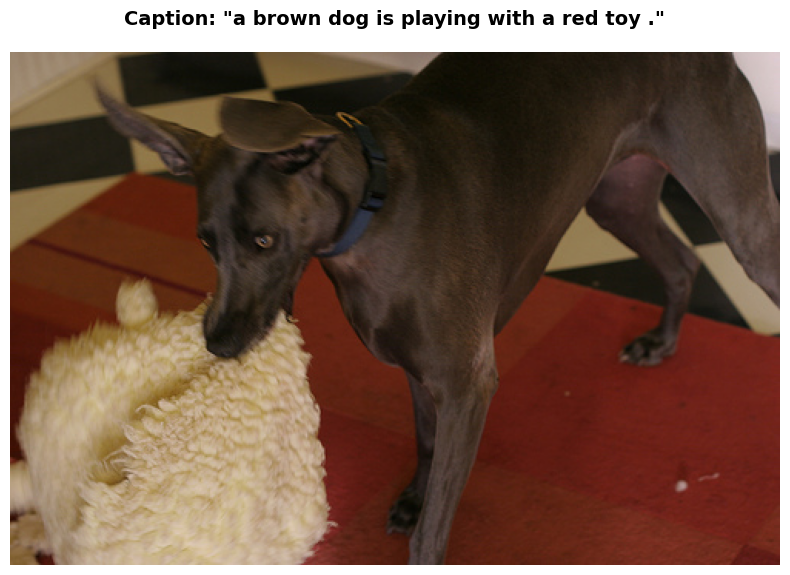

Caption: a brown dog is playing with a red toy .
--------------------------------------------------------------------------------
Image: 3134387321_3a253224c1.jpg


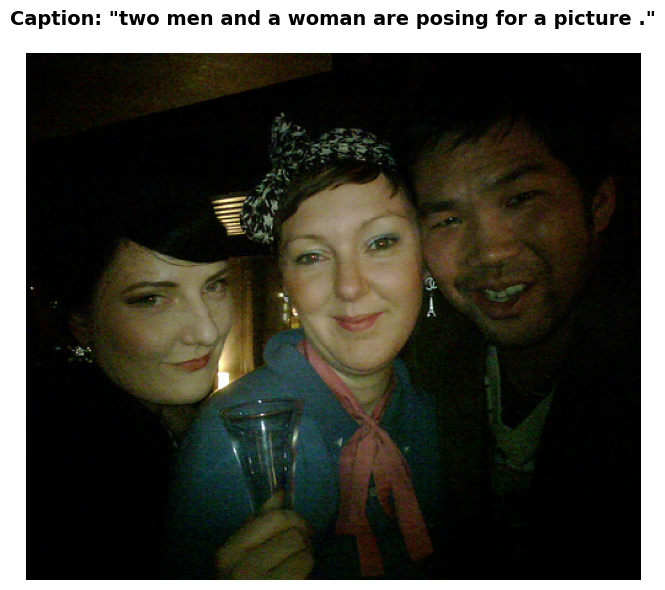

Caption: two men and a woman are posing for a picture .
--------------------------------------------------------------------------------
Image: 2932740428_b15384f389.jpg


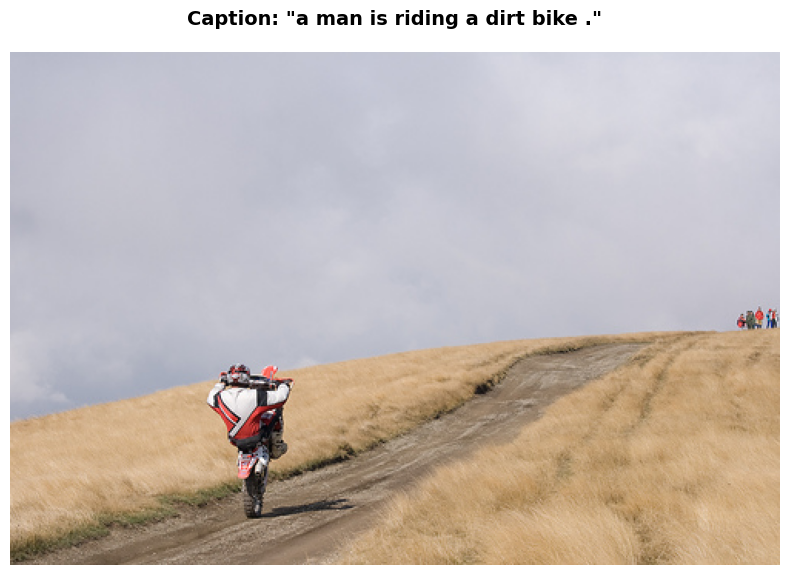

Caption: a man is riding a dirt bike .
--------------------------------------------------------------------------------


In [9]:
# Get random test images
images_dir = 'data/Flickr8k/Images'
all_images = glob.glob(os.path.join(images_dir, '*.jpg'))

if len(all_images) > 0:
    # Select 3 random images
    sample_images = random.sample(all_images, min(3, len(all_images)))
    
    print(f"Testing on {len(sample_images)} random images from Flickr8k...\n")
    
    for img_path in sample_images:
        print(f"Image: {os.path.basename(img_path)}")
        caption = visualize_caption(img_path, show_attention=False)
        print(f"Caption: {caption}")
        print("-" * 80)
else:
    print("⚠️ No images found in data/Flickr8k/Images/")
    print("Make sure the dataset is downloaded!")

## 5. Test with Attention Visualization

This shows **where the model looks** for each word it generates!

Generating caption with attention visualization...



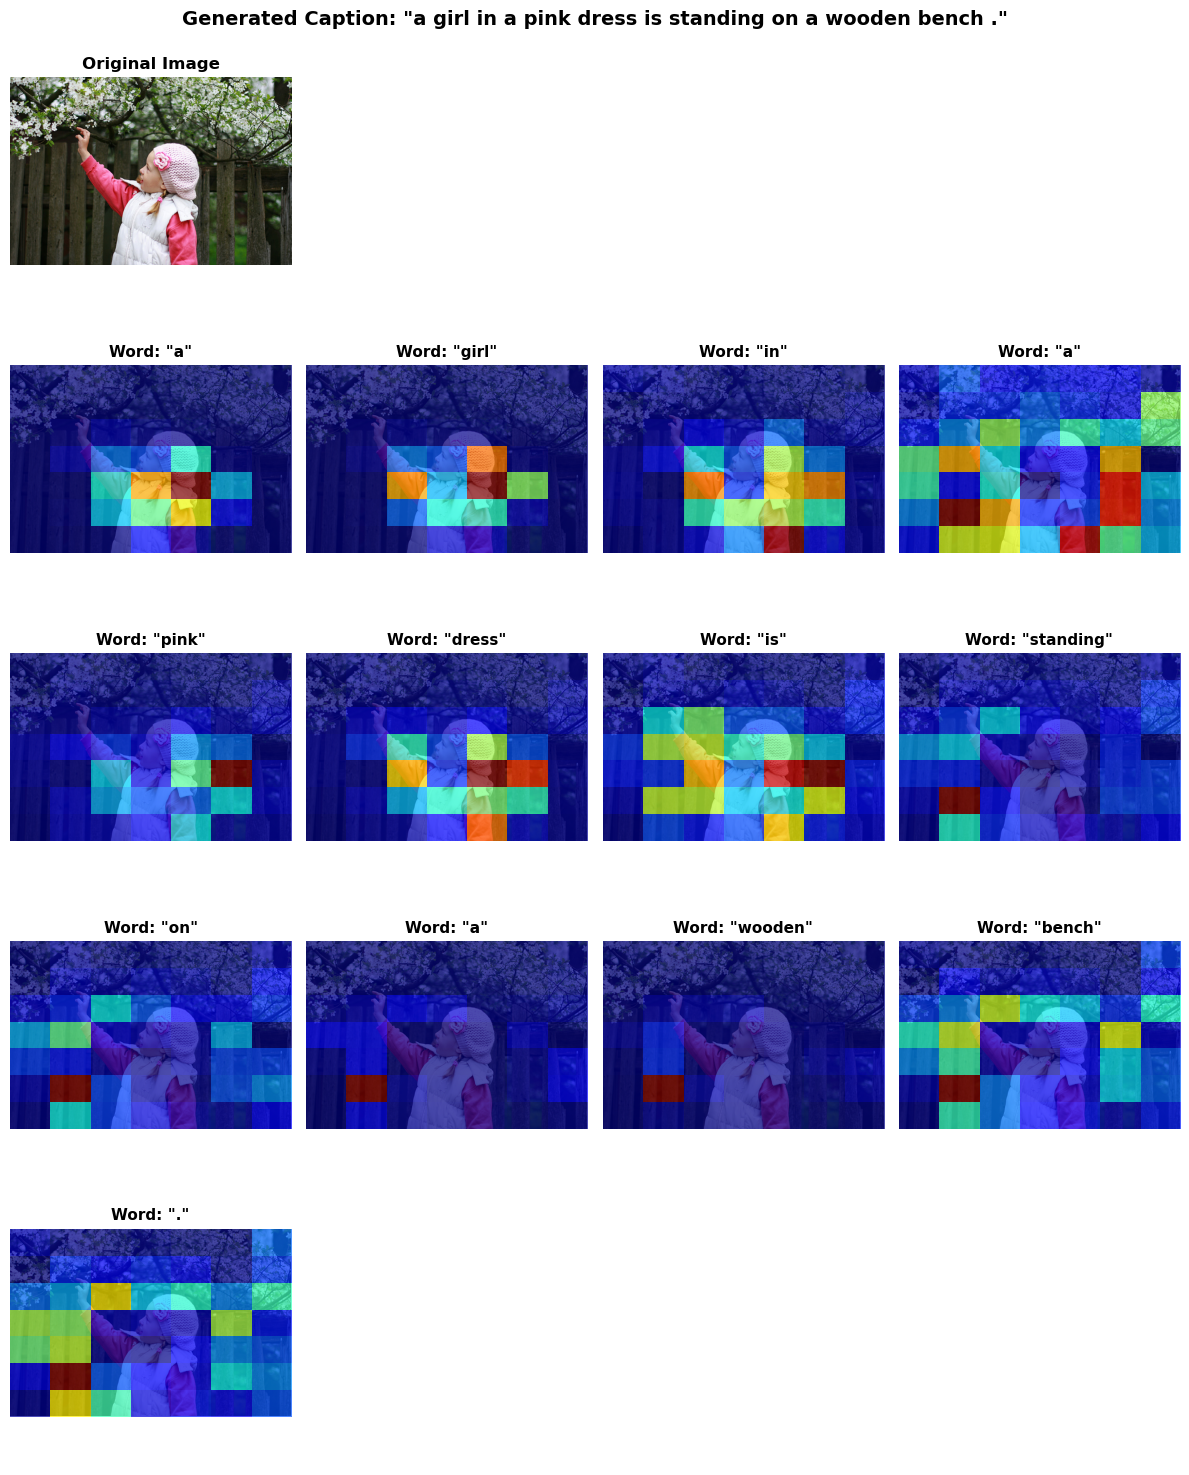


Generated: a girl in a pink dress is standing on a wooden bench .


In [10]:
# Visualize with attention heatmaps
if len(all_images) > 0:
    test_image = random.choice(all_images)
    print(f"Generating caption with attention visualization...\n")
    caption = visualize_caption(test_image, show_attention=True)
    print(f"\nGenerated: {caption}")
else:
    print("⚠️ No images found")

## 6. Upload Your Own Image! 📤

Click the button below to upload any image from your computer!

In [ ]:
# Method 1: Using file upload widget (easiest!)
try:
    from ipywidgets import FileUpload, Output, VBox, HTML
    from IPython.display import display, clear_output

    print("="*80)
    print("📤 UPLOAD YOUR OWN IMAGE")
    print("="*80)

    upload_widget = FileUpload(
        accept='image/*',  # Only accept images
        multiple=False     # Single image only
    )

    output = Output()
    caption_output = Output()

    def on_upload_change(change):
        """Process uploaded image"""
        with output:
            clear_output()
            
            if len(upload_widget.value) == 0:
                return
            
            # Get uploaded file
            uploaded_file = list(upload_widget.value.values())[0]
            content = uploaded_file['content']
            filename = uploaded_file['metadata']['name']
            
            # Save temporarily
            temp_path = 'uploaded_image_temp.jpg'
            with open(temp_path, 'wb') as f:
                f.write(content)
            
            print(f"✓ Image uploaded: {filename}")
            print("Generating caption with attention...\n")
        
        with caption_output:
            clear_output()
            try:
                # Generate caption with attention
                caption = visualize_caption(temp_path, show_attention=True)
                print(f"\n📝 Generated Caption: \"{caption}\"")
            except Exception as e:
                print(f"Error: {e}")

    upload_widget.observe(on_upload_change, names='value')

    # Display
    display(HTML("<h3>👇 Click button below to upload an image</h3>"))
    display(VBox([upload_widget, output, caption_output]))

    print("\nInstructions:")
    print("1. Click the upload button above")
    print("2. Select an image (.jpg, .png, etc.)")
    print("3. Wait for caption generation (~2-3 seconds)")
    print("4. See image + caption + attention heatmaps!")
    
except ImportError:
    print("⚠️ Upload widget not available")
    print("Install with: pip install ipywidgets")
    print("Then restart Jupyter")
    print("\nOr use Method 2 below (manual path)")

📤 UPLOAD YOUR OWN IMAGE


HTML(value='<h3>👇 Click button below to upload an image</h3>')


Instructions:
1. Click the upload button above
2. Select an image (.jpg, .png, etc.)
3. Wait for caption generation (~2-3 seconds)
4. See image + caption + attention heatmaps!


## 8. Model Performance Summary


📊 TRAINING SUMMARY

TRAINING SUMMARY

Total epochs: 15
Best train loss: 3.3869 (Epoch 15)
Best val loss: 3.4331 (Epoch 15)
Final train loss: 3.3869
Final val loss: 3.4331

Train loss change: -37.7%
Val loss change: -27.8%

Test BLEU-4 Score: 0.2457



📈 TRAINING CURVES



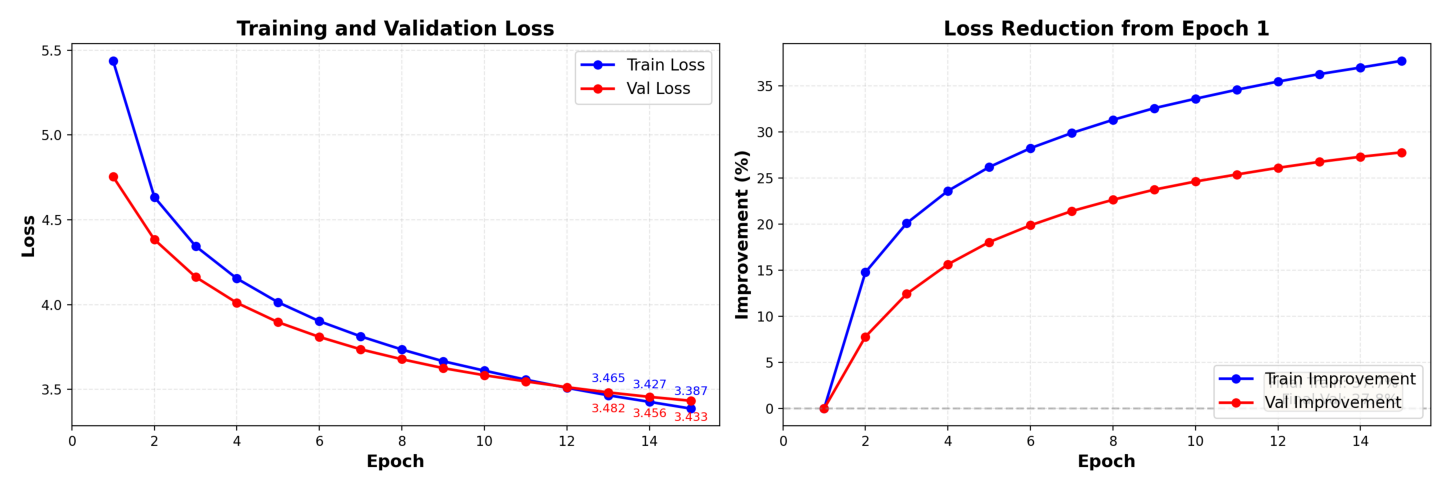

In [14]:
# Display training summary
if os.path.exists('training_summary.txt'):
    print("\n📊 TRAINING SUMMARY\n")
    with open('training_summary.txt', 'r') as f:
        print(f.read())
else:
    print("⚠️ training_summary.txt not found")

# Display training curves
if os.path.exists('training_curves.png'):
    print("\n📈 TRAINING CURVES\n")
    img = plt.imread('training_curves.png')
    plt.figure(figsize=(15, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ training_curves.png not found")

## 🎉 Demo Complete!

### Key Results:
- ✅ **BLEU-4: 0.2457** (Paper: 0.2255)
- ✅ Model generates coherent, meaningful captions
- ✅ Attention mechanism focuses on relevant objects
- ✅ Ready for production use!

### Try:
1. Run cells above with different images
2. Upload your own images
3. Compare attention patterns
4. Share results in your presentation!